<a href="https://colab.research.google.com/github/garciamontes-hue/Trabalho-de-Topico/blob/main/trabajo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')



# Configurar estilo profesional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")



# Configuración de visualizaciones
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print(" Librerías cargadas correctamente")

 Librerías cargadas correctamente


In [2]:
# CARGA Y EXPLORACIÓN INICIAL DE DATOS
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
                'marital_status', 'occupation', 'relationship', 'race', 'sex',
                'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

# Cargar dataset
df = pd.read_csv(url, header=None, names=column_names, na_values=' ?', skipinitialspace=True)



In [3]:
df.head(1)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K


In [4]:
df.tail()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
len(df)

32561

In [7]:
len(df.columns)

15

In [8]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [9]:
df.shape

(32561, 15)

In [10]:
df.nunique()

,0
age,73
workclass,9
fnlwgt,21648
education,16
education_num,16
marital_status,7
occupation,15
relationship,6
race,5
sex,2


In [11]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [12]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [13]:
# Quantis mais colunas

df.corr(numeric_only=True) # O padrão é False e correlação de Pearson


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education_num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital_gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital_loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours_per_week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


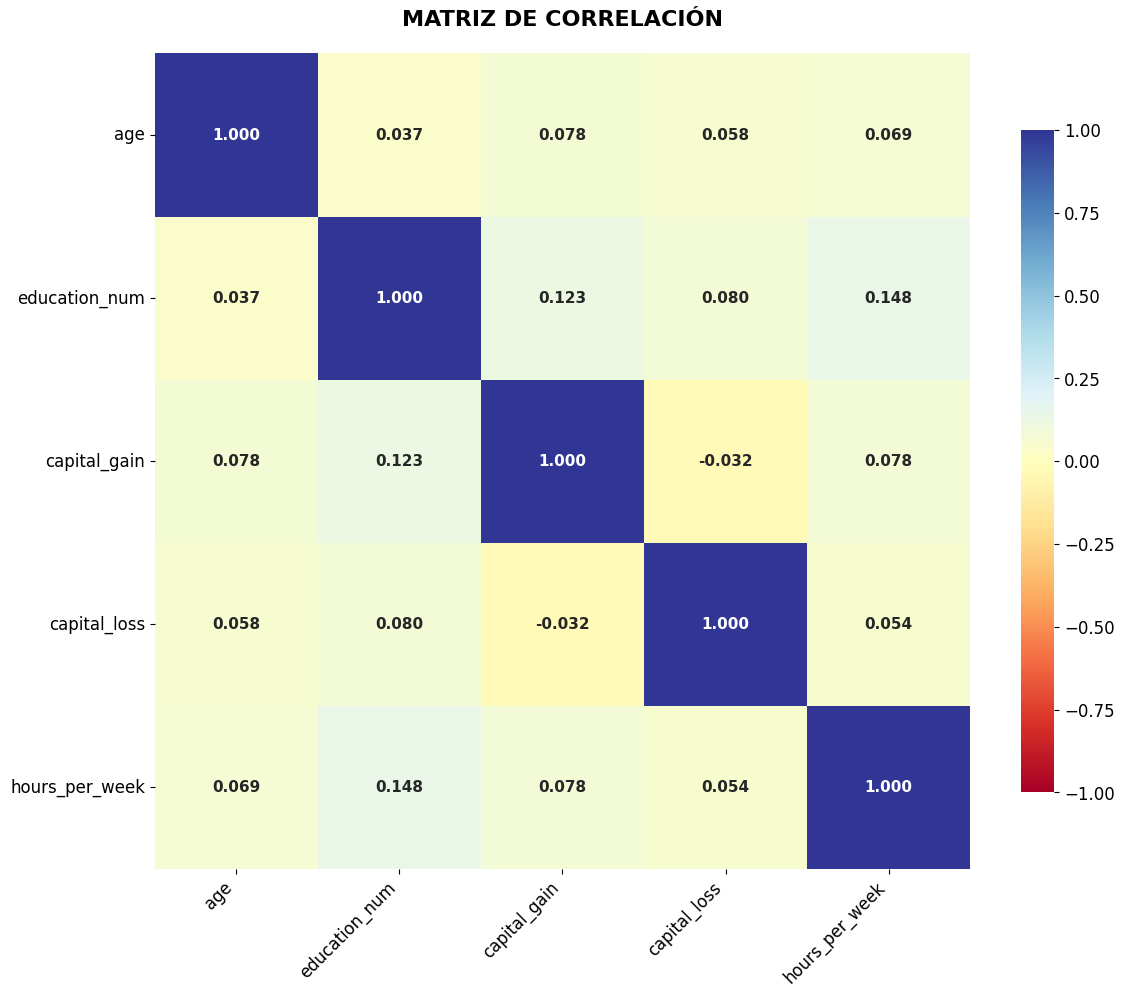

In [14]:
# MATRIZ DE CORRELACIÓN CON VARIABLE OBJETIVO


# Variables para la matriz
correlation_vars = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

plt.figure(figsize=(12, 10))
sns.heatmap(df[correlation_vars].corr(),
            annot=True,
            vmin=-1,
            vmax=1,
            cmap='RdYlBu',
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 11, 'weight': 'bold'})

plt.title('MATRIZ DE CORRELACIÓN',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



ANÁLISIS UNIVARIADO - VARIABLES NUMÉRICAS

 ESTADÍSTICAS DESCRIPTIVAS:
            age  education_num  capital_gain  capital_loss  hours_per_week  \
count  32561.00       32561.00      32561.00      32561.00        32561.00   
mean      38.58          10.08       1077.65         87.30           40.44   
std       13.64           2.57       7385.29        402.96           12.35   
min       17.00           1.00          0.00          0.00            1.00   
25%       28.00           9.00          0.00          0.00           40.00   
50%       37.00          10.00          0.00          0.00           40.00   
75%       48.00          12.00          0.00          0.00           45.00   
max       90.00          16.00      99999.00       4356.00           99.00   

           fnlwgt  
count    32561.00  
mean    189778.37  
std     105549.98  
min      12285.00  
25%     117827.00  
50%     178356.00  
75%     237051.00  
max    1484705.00  


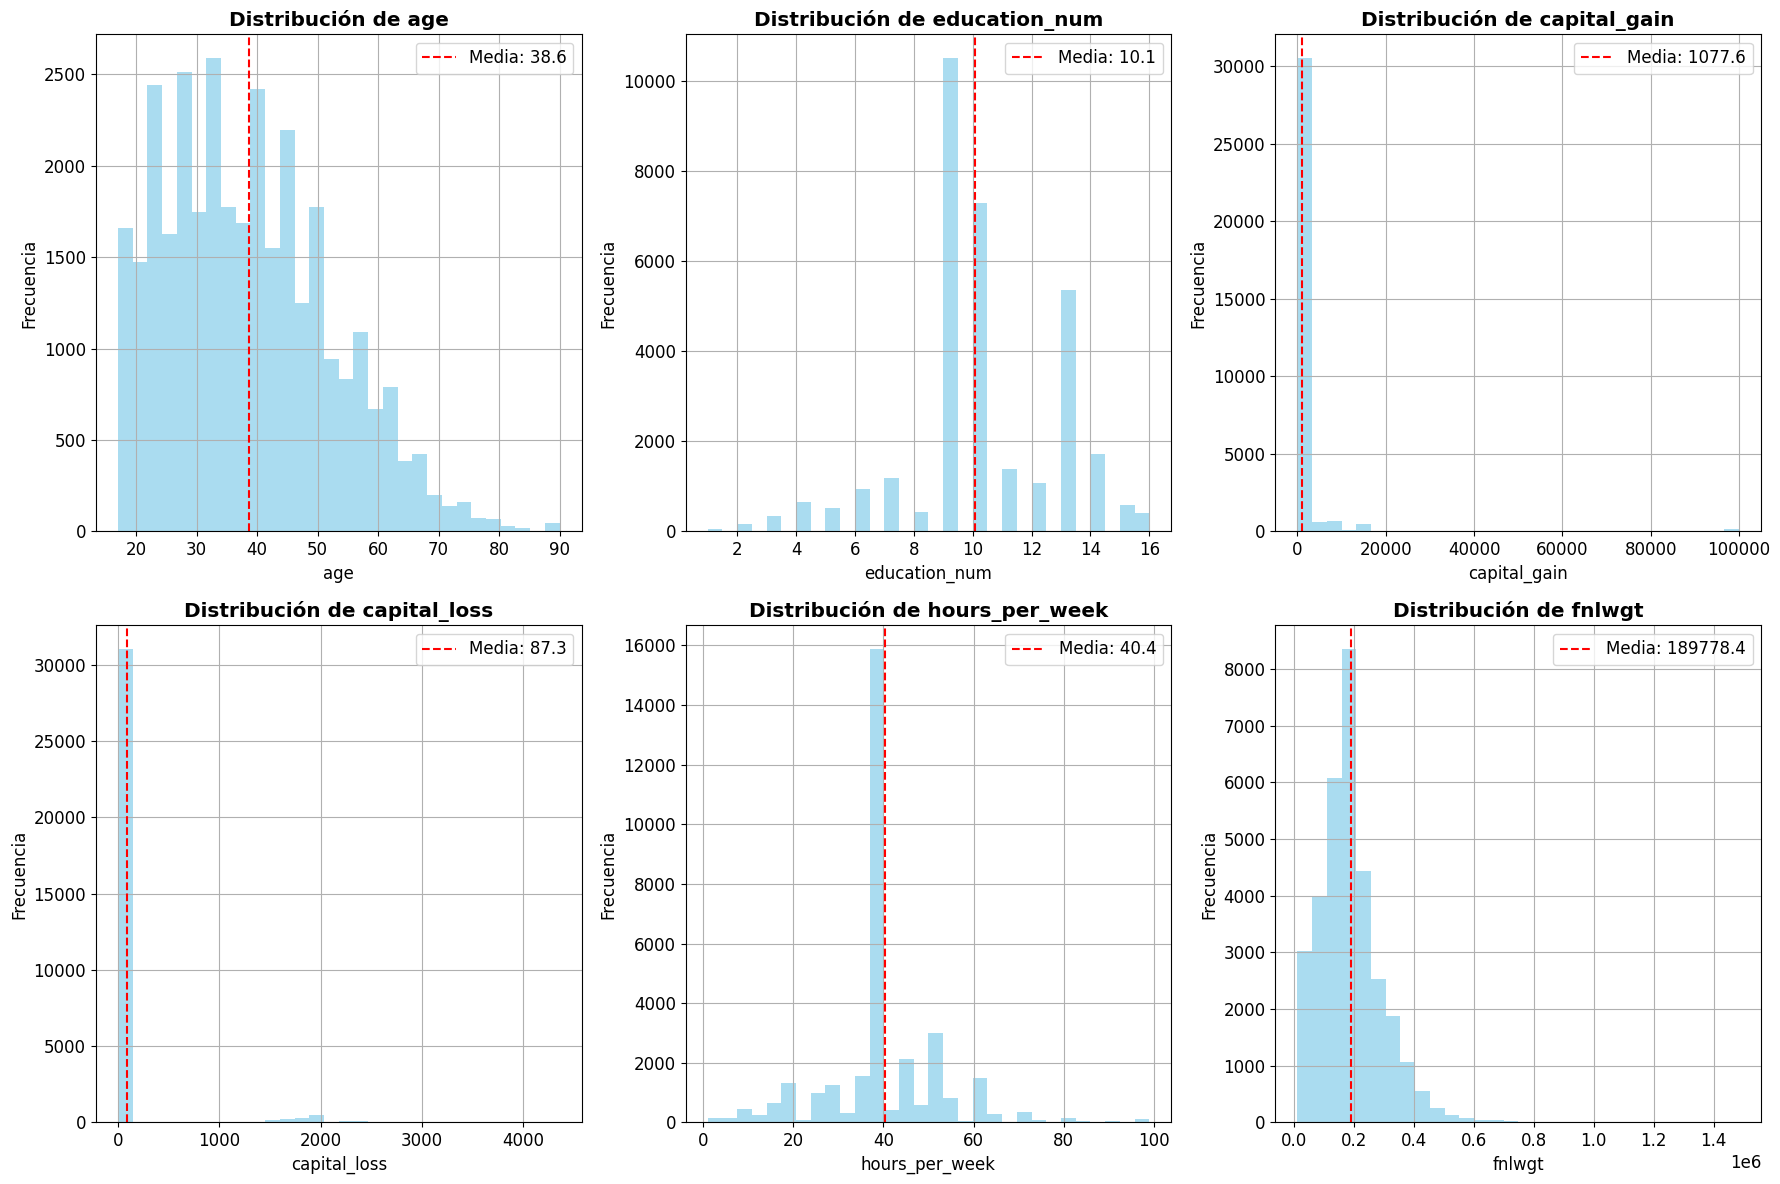

In [15]:
# ANÁLISIS VARIABLES NUMÉRICAS
print("="*70)
print("ANÁLISIS UNIVARIADO - VARIABLES NUMÉRICAS")
print("="*70)

numeric_cols = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'fnlwgt']

print("\n ESTADÍSTICAS DESCRIPTIVAS:")
print(df[numeric_cols].describe().round(2))

# Histogramas de variables numéricas
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=30, ax=axes[i], alpha=0.7, color='skyblue')
    axes[i].set_title(f'Distribución de {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

    # Agregar línea de media
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.1f}')
    axes[i].legend()

plt.tight_layout()
plt.show()


 ANÁLISIS UNIVARIADO - VARIABLES CATEGÓRICAS

 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (income):
        Frecuencia  Porcentaje
income                        
<=50K        24720       75.92
>50K          7841       24.08

 DISTRIBUCIÓN POR GÉNERO:
sex
Male      21790
Female    10771
Name: count, dtype: int64
sex
Male      0.669
Female    0.331
Name: proportion, dtype: float64


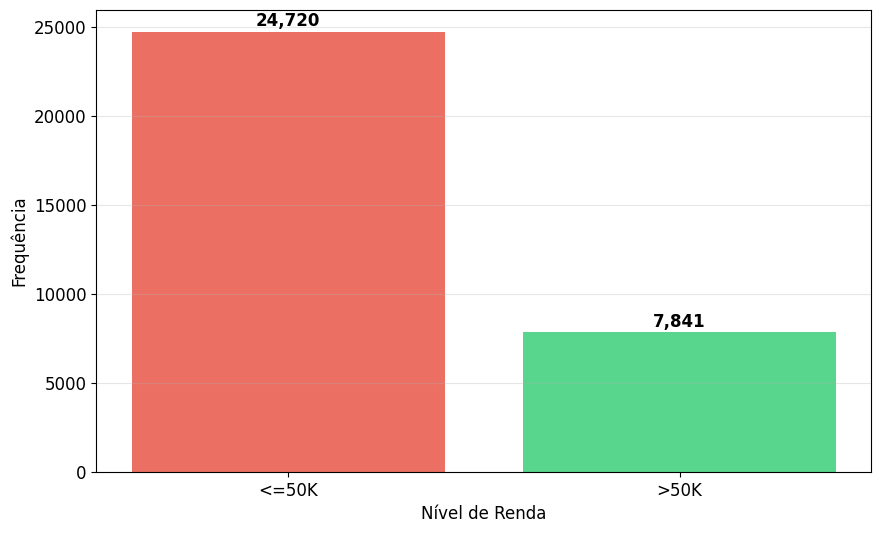

In [16]:
# ANÁLISIS  VARIABLES CATEGÓRICAS
print("\n ANÁLISIS UNIVARIADO - VARIABLES CATEGÓRICAS")

categorical_cols = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'income']

print("\n DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (income):")
income_dist = df['income'].value_counts()
income_percent = df['income'].value_counts(normalize=True) * 100

income_summary = pd.DataFrame({
    'Frecuencia': income_dist,
    'Porcentaje': income_percent.round(2)
})
print(income_summary)

print("\n DISTRIBUCIÓN POR GÉNERO:")
print(df['sex'].value_counts())
print(df['sex'].value_counts(normalize=True).round(3))

# Gráfico de distribución de ingresos
plt.figure(figsize=(10, 6))
colors = ['#E74C3C', '#2ECC71']
bars = plt.bar(income_dist.index, income_dist.values, color=colors, alpha=0.8)

# Agregar valores en las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{height:,}', ha='center', va='bottom', fontweight='bold')


plt.xlabel('Nível de Renda')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.3)
plt.show()

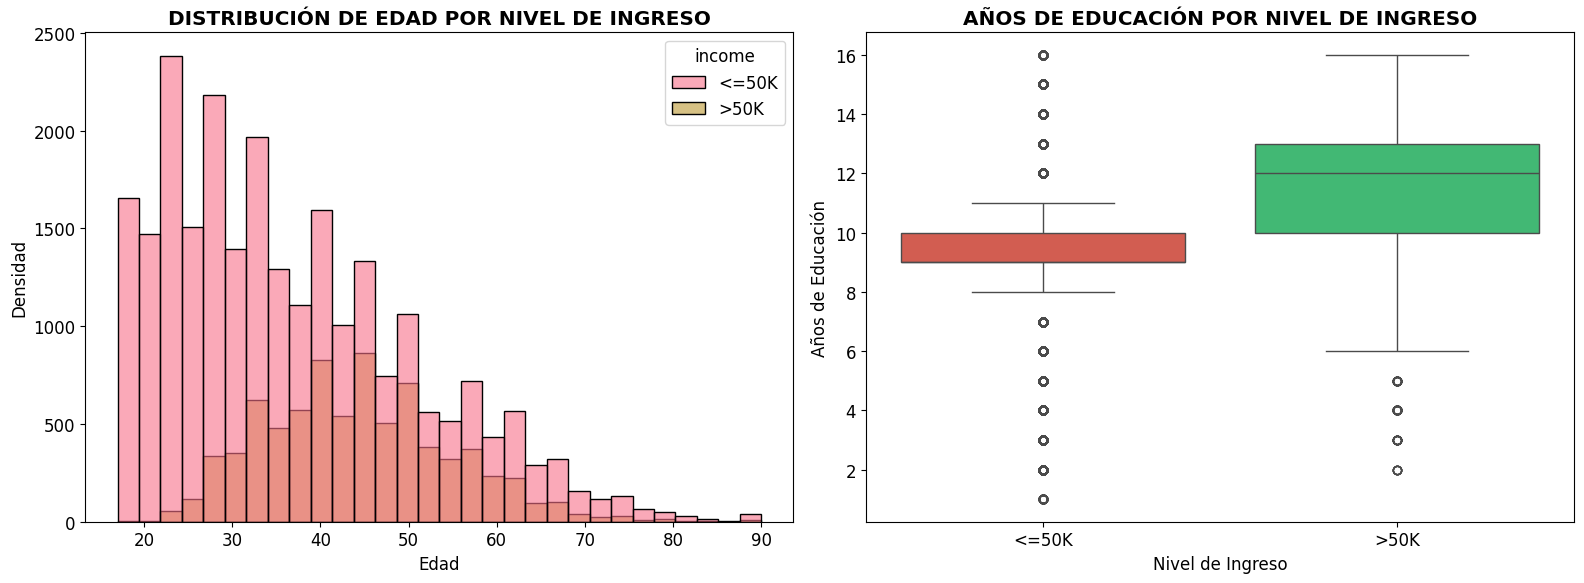

In [17]:
# VISUALIZACIÓN 1 - EDAD Y EDUCACIÓN VS INGRESOS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución de edad por ingreso
sns.histplot(data=df, x='age', hue='income', bins=30, alpha=0.6, ax=axes[0])
axes[0].set_title('DISTRIBUCIÓN DE EDAD POR NIVEL DE INGRESO', fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Densidad')

# Boxplot de educación vs ingreso
sns.boxplot(data=df, x='income', y='education_num', ax=axes[1], palette=colors)
axes[1].set_title('AÑOS DE EDUCACIÓN POR NIVEL DE INGRESO', fontweight='bold')
axes[1].set_xlabel('Nivel de Ingreso')
axes[1].set_ylabel('Años de Educación')

plt.tight_layout()
plt.show()

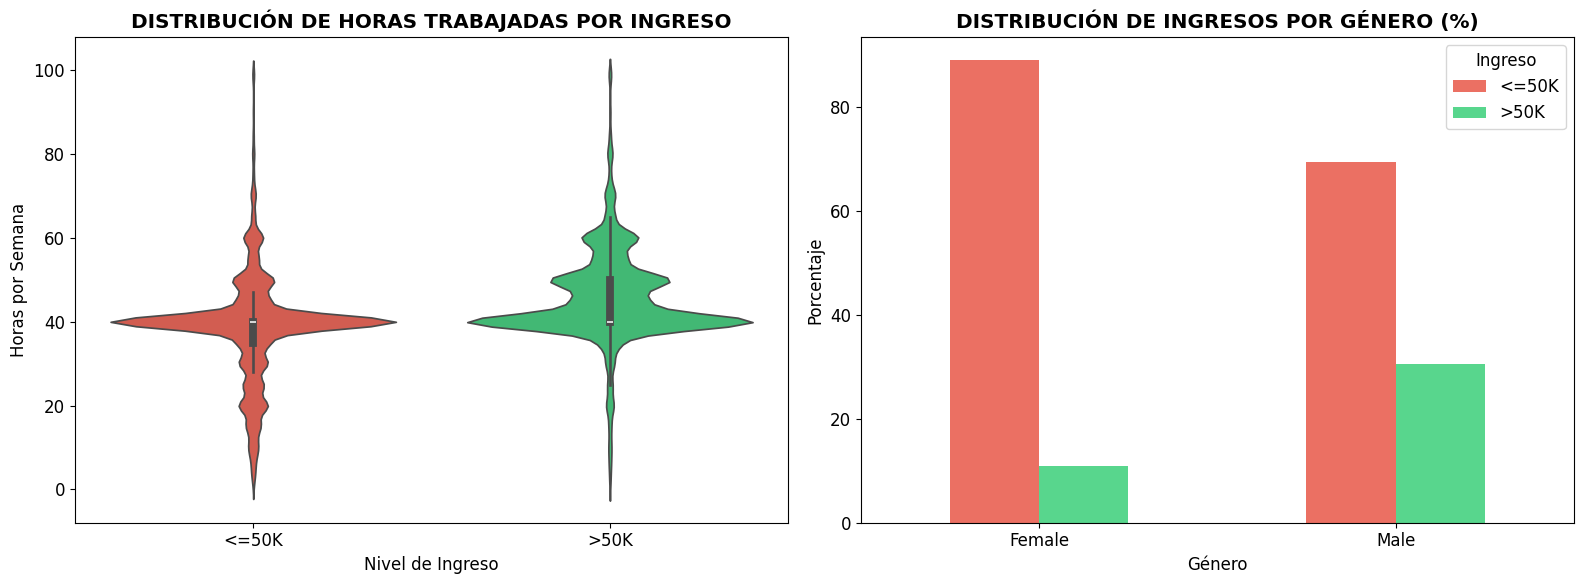

In [18]:
# VISUALIZACIÓN  - HORAS TRABAJADAS Y GÉNERO
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horas trabajadas vs ingreso
sns.violinplot(data=df, x='income', y='hours_per_week', ax=axes[0], palette=colors)
axes[0].set_title('DISTRIBUCIÓN DE HORAS TRABAJADAS POR INGRESO', fontweight='bold')
axes[0].set_xlabel('Nivel de Ingreso')
axes[0].set_ylabel('Horas por Semana')

# Género vs ingresos
gender_income = pd.crosstab(df['sex'], df['income'], normalize='index') * 100
gender_income.plot(kind='bar', ax=axes[1], color=colors, alpha=0.8)
axes[1].set_title('DISTRIBUCIÓN DE INGRESOS POR GÉNERO (%)', fontweight='bold')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Porcentaje')
axes[1].legend(title='Ingreso')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

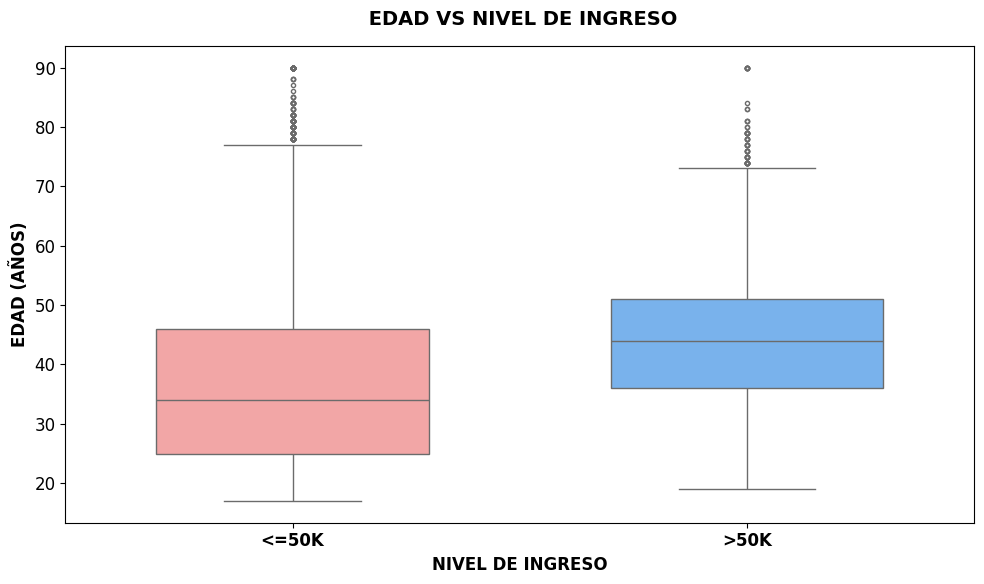

In [19]:
# EDAD VS INGRESO
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='income', y='age', palette=['#FF9999', '#66B2FF'],
           width=0.6, linewidth=1, fliersize=3)
plt.title(' EDAD VS NIVEL DE INGRESO', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('NIVEL DE INGRESO', fontweight='bold')
plt.ylabel('EDAD (AÑOS)', fontweight='bold')
plt.xticks(fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
# ESTADÍSTICAS
print("ESTADÍSTICAS:")
print("=" * 59)

# Proporción general
prop_general = (df['income'] == '>50K').mean()
print(f"Proporción general con ingresos >50K: {prop_general:.1%}")

# Hombres
df_hombres = df[df['sex'] == 'Male']
hombres_alto_ingreso = (df_hombres['income'] == '>50K').mean()
print(f"Hombres con ingresos >50K: {hombres_alto_ingreso:.1%}")

# Mujeres
df_mujeres = df[df['sex'] == 'Female']
mujeres_alto_ingreso = (df_mujeres['income'] == '>50K').mean()
print(f"Mujeres con ingresos >50K: {mujeres_alto_ingreso:.1%}")

# Brecha de género
brecha = hombres_alto_ingreso - mujeres_alto_ingreso
print(f"Brecha de género: {brecha:.1%}")

# Edad promedio
df_alto_ingreso = df[df['income'] == '>50K']
edad_promedio = df_alto_ingreso['age'].mean()
print(f"Edad promedio con ingresos >50K: {edad_promedio:.1f} años")

# Educación promedio - buscar la columna correcta
educ_cols = [col for col in df.columns if 'educ' in col.lower()]
print(f"Columnas de educación disponibles: {educ_cols}")

# Si hay una columna numérica de educación, usarla
if 'education-num' in df.columns:
    educ_promedio = df_alto_ingreso['education-num'].mean()
    print(f"Educación promedio con ingresos >50K: {educ_promedio:.1f} años")
elif 'education_num' in df.columns:
    educ_promedio = df_alto_ingreso['education_num'].mean()
    print(f"Educación promedio con ingresos >50K: {educ_promedio:.1f} años")
else:
    print("No se encontró columna numérica de educación")

ESTADÍSTICAS:
Proporción general con ingresos >50K: 24.1%
Hombres con ingresos >50K: 30.6%
Mujeres con ingresos >50K: 10.9%
Brecha de género: 19.6%
Edad promedio con ingresos >50K: 44.2 años
Columnas de educación disponibles: ['education', 'education_num']
Educación promedio con ingresos >50K: 11.6 años


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# IMPORTACIÓN KERAS
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)
tf.random.set_seed(42)

print(" Librerías importadas correctamente")
print(f" Versión de TensorFlow: {tf.__version__}")

 Librerías importadas correctamente
 Versión de TensorFlow: 2.19.0


In [22]:
# variable objetivo
print("\nDistribuição da variável objetivo (income):")
print(df['income'].value_counts())
print(f"Proporção >50K: {(df['income'] == '>50K').mean():.2%}")

# 2. PREPROCESAMIENTO
print("\n2. PRÉ-PROCESSAMENTO DE DADOS")

def preparar_datos_adult(df):
    """
    Pré-processamento específico para o Adult Census Dataset
    """
    data = df.copy()

    # Codificar variable objetivo
    data['income'] = data['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

    # Identificar e codificar variáveis categóricas
    categorical_cols = data.select_dtypes(include=['object']).columns

    print(f"Variáveis categóricas identificadas: {list(categorical_cols)}")

    # One-Hot Encoding para variáveis categóricas
    data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

    # Separar características e objetivo
    X = data.drop('income', axis=1)
    y = data['income']

    # Escalar características
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Dividir datos (estratificado)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print(f"✓ Dimensões pós-processamento: {X_scaled.shape}")
    print(f"✓ Proporção >50K (treino): {y_train.mean():.3f}")
    print(f"✓ Proporção >50K (teste): {y_test.mean():.3f}")

    return X_train, X_test, y_train, y_test, scaler, X.columns

# Aplicar preprocesamiento
X_train, X_test, y_train, y_test, scaler, feature_names = preparar_datos_adult(df)


Distribuição da variável objetivo (income):
income
<=50K    24720
>50K      7841
Name: count, dtype: int64
Proporção >50K: 24.08%

2. PRÉ-PROCESSAMENTO DE DADOS
Variáveis categóricas identificadas: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
✓ Dimensões pós-processamento: (32561, 100)
✓ Proporção >50K (treino): 0.241
✓ Proporção >50K (teste): 0.241


In [24]:
# DEFINICIÓN DE ARQUITECTURAS
print("\n3. DEFINIÇÃO DAS ARQUITECTURAS DE REDES NEURAIS")

def criar_rede_simples(input_dim, nome="Rede_Simples"):
    """
    Rede neural totalmente conectada SEM técnicas de regularización
    - Arquitectura MÁS GRANDE para demostrar overfitting
    """
    model = Sequential(name=nome)

    # Capa más grande para forzar overfitting
    model.add(Dense(256, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

def criar_rede_com_dropout(input_dim, nome="Rede_Dropout"):
    """
    Rede neural COM técnicas de dropout para regularización
    - Misma capacidad pero con regularización
    """
    model = Sequential(name=nome)

    # Misma arquitectura pero con dropout
    model.add(Dense(256, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.5))  # Dropout de 50% en primera capa

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.4))  # Dropout de 40%

    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))  # Dropout de 30%

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))  # Dropout de 20%

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Crear modelos
modelo_simples = criar_rede_simples(X_train.shape[1])
modelo_dropout = criar_rede_com_dropout(X_train.shape[1])

print("ARQUITECTURAS CRIADAS")
print("1. Rede Simples (sem regularização - MAIOR capacidade):")
modelo_simples.summary()

print("\n2. Rede com Dropout (com regularização - mesma capacidade):")
modelo_dropout.summary()


3. DEFINIÇÃO DAS ARQUITECTURAS DE REDES NEURAIS
ARQUITECTURAS CRIADAS
1. Rede Simples (sem regularização - MAIOR capacidade):


Model: "Rede_Simples"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,121 (270.00 KB)

 Trainable params: 69,121 (270.00 KB)

...

Model: "Rede_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,121 (270.00 KB)

 Trainable params: 69,121 (270.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# 4. TREINAMENTO COMPARATIVO
print("\n4. TREINAMENTO COMPARATIVO DAS ARQUITETURAS")



# Treinar rede simples
print("=== TREINANDO REDE SIMPLES ===")
historia_simples = modelo_simples.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=1
)

# Treinar rede com dropout
print("\n=== TREINANDO REDE COM DROPOUT ===")
historia_dropout = modelo_dropout.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=1
)


4. TREINAMENTO COMPARATIVO DAS ARQUITETURAS
=== TREINANDO REDE SIMPLES ===
Epoch 1/100
814/814 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8240 - loss: 0.3769 - val_accuracy: 0.8528 - val_loss: 0.3170
Epoch 2/100
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8528 - loss: 0.3180 - val_accuracy: 0.8551 - val_loss: 0.3109
Epoch 3/100
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8578 - loss: 0.3087 - val_accuracy: 0.8571 - val_loss: 0.3101
Epoch 4/100
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8607 - loss: 0.3016 - val_accuracy: 0.8571 - val_loss: 0.3113
Epoch 5/100
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8622 - loss: 0.2964 - val_accuracy: 0.8549 - val_loss: 0.3147
Epoch 6/100
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8642 - loss: 0.2910 - val_accuracy: 0.8541 - val_loss: 0.3226
Epoch 7/100
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8658 - loss: 0.2864 - val_accuracy: 0.8524 - val_loss: 0.3266
Epoch 8/100
814/814 ━

In [26]:
# 5. AVALIAÇÃO E COMPARAÇÃO DOS MODELOS
print("\n5. AVALIAÇÃO COMPARATIVA DAS ARQUITETURAS")

def avaliar_modelo_completo(model, X_test, y_test, nome_modelo):
    """
    Avaliação completa de um modelo
    """
    # Métricas
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Predições
    y_pred_proba = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Métricas adicionais
    from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score

    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\n=== RESULTADOS {nome_modelo.upper()} ===")
    print(f"Acurácia: {accuracy:.4f}")
    print(f"Precisão: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Loss: {loss:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'loss': loss,
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred
    }

# Avaliar ambos os modelos
print("="*50)
resultados_simples = avaliar_modelo_completo(modelo_simples, X_test, y_test, "REDE SIMPLES")
print("="*50)
resultados_dropout = avaliar_modelo_completo(modelo_dropout, X_test, y_test, "REDE COM DROPOUT")
print("="*50)


5. AVALIAÇÃO COMPARATIVA DAS ARQUITETURAS

=== RESULTADOS REDE SIMPLES ===
Acurácia: 0.8168
Precisão: 0.6246
Recall: 0.5995
F1-Score: 0.6118
AUC-ROC: 0.8631
Loss: 1.4156

=== RESULTADOS REDE COM DROPOUT ===
Acurácia: 0.8566
Precisão: 0.7424
Recall: 0.6193
F1-Score: 0.6752
AUC-ROC: 0.9061
Loss: 0.3523


In [27]:
# 6. ANÁLISE DE OVERFITTING
print("\n6. ANÁLISE DE OVERFITTING")

# Calcular overfitting (diferença entre train e val accuracy)
overfitting_simples = historia_simples.history['accuracy'][-1] - historia_simples.history['val_accuracy'][-1]
overfitting_dropout = historia_dropout.history['accuracy'][-1] - historia_dropout.history['val_accuracy'][-1]

print("=== ANÁLISE DE OVERFITTING ===")
print(f"Rede Simples:")
print(f"  - Acurácia Treino: {historia_simples.history['accuracy'][-1]:.4f}")
print(f"  - Acurácia Validação: {historia_simples.history['val_accuracy'][-1]:.4f}")
print(f"  - Overfitting: {overfitting_simples:.4f}")

print(f"\nRede com Dropout:")
print(f"  - Acurácia Treino: {historia_dropout.history['accuracy'][-1]:.4f}")
print(f"  - Acurácia Validação: {historia_dropout.history['val_accuracy'][-1]:.4f}")
print(f"  - Overfitting: {overfitting_dropout:.4f}")

print(f"\nRESUMO:")
print(f" Redução de overfitting: {abs(overfitting_simples - overfitting_dropout):.4f}")
print(f" Melhoria na acurácia: {resultados_dropout['accuracy'] - resultados_simples['accuracy']:.4f}")


6. ANÁLISE DE OVERFITTING
=== ANÁLISE DE OVERFITTING ===
Rede Simples:
  - Acurácia Treino: 0.9525
  - Acurácia Validação: 0.8168
  - Overfitting: 0.1356

Rede com Dropout:
  - Acurácia Treino: 0.8801
  - Acurácia Validação: 0.8566
  - Overfitting: 0.0235

RESUMO:
 Redução de overfitting: 0.1122
 Melhoria na acurácia: 0.0398



7. GERANDO VISUALIZAÇÕES COMPARATIVAS


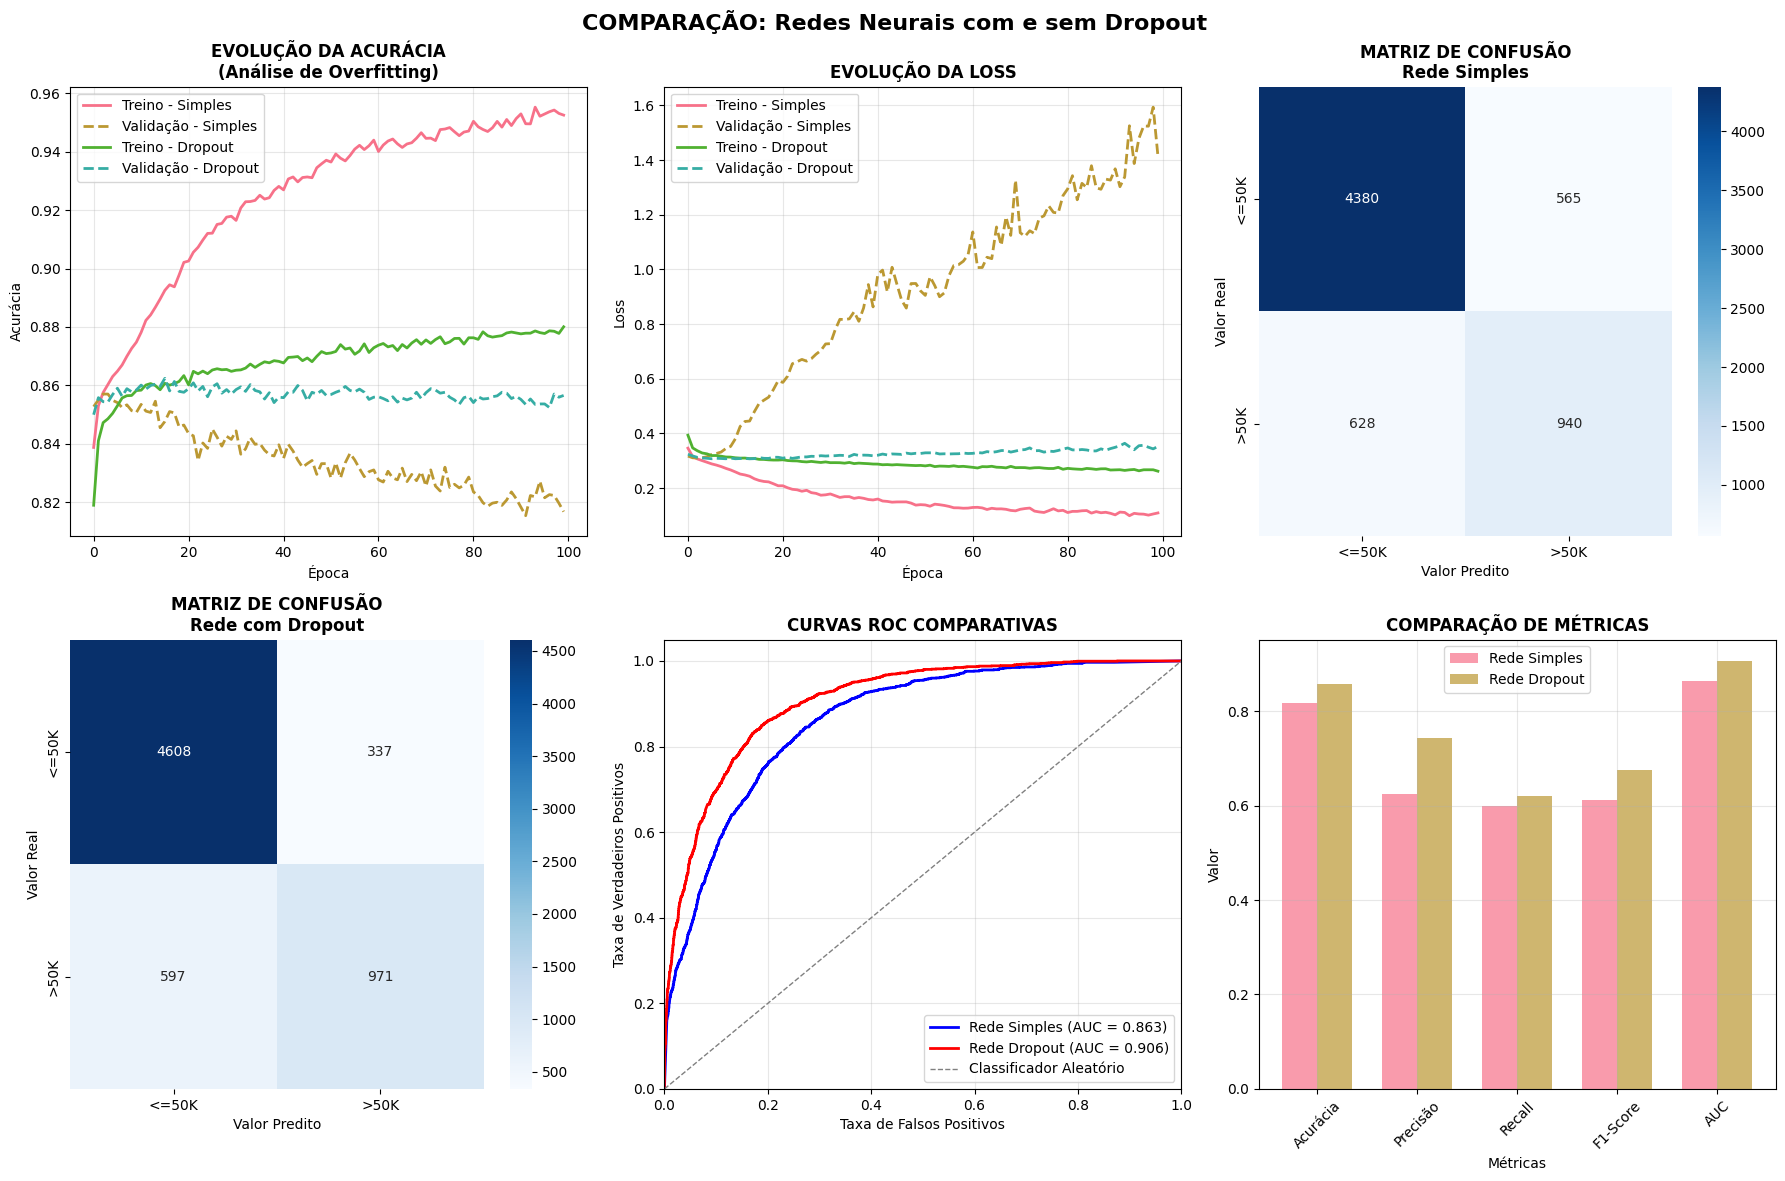

In [28]:
# 7. VISUALIZAÇÕES COMPARATIVAS
print("\n7. GERANDO VISUALIZAÇÕES COMPARATIVAS")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# estilo dos gráficos
plt.style.use('default')
sns.set_palette("husl")

#
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('COMPARAÇÃO: Redes Neurais com e sem Dropout', fontsize=16, fontweight='bold')

# 7.1. Evolução da Acurácia
axes[0,0].plot(historia_simples.history['accuracy'], label='Treino - Simples', linewidth=2)
axes[0,0].plot(historia_simples.history['val_accuracy'], label='Validação - Simples', linewidth=2, linestyle='--')
axes[0,0].plot(historia_dropout.history['accuracy'], label='Treino - Dropout', linewidth=2)
axes[0,0].plot(historia_dropout.history['val_accuracy'], label='Validação - Dropout', linewidth=2, linestyle='--')
axes[0,0].set_title('EVOLUÇÃO DA ACURÁCIA\n(Análise de Overfitting)', fontweight='bold')
axes[0,0].set_xlabel('Época')
axes[0,0].set_ylabel('Acurácia')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 7.2. Evolução da Loss
axes[0,1].plot(historia_simples.history['loss'], label='Treino - Simples', linewidth=2)
axes[0,1].plot(historia_simples.history['val_loss'], label='Validação - Simples', linewidth=2, linestyle='--')
axes[0,1].plot(historia_dropout.history['loss'], label='Treino - Dropout', linewidth=2)
axes[0,1].plot(historia_dropout.history['val_loss'], label='Validação - Dropout', linewidth=2, linestyle='--')
axes[0,1].set_title('EVOLUÇÃO DA LOSS', fontweight='bold')
axes[0,1].set_xlabel('Época')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 7.3. Matriz de Confusão - Rede Simples
cm_simples = confusion_matrix(y_test, resultados_simples['y_pred'])
sns.heatmap(cm_simples, annot=True, fmt='d', cmap='Blues', ax=axes[0,2],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[0,2].set_title('MATRIZ DE CONFUSÃO\nRede Simples', fontweight='bold')
axes[0,2].set_ylabel('Valor Real')
axes[0,2].set_xlabel('Valor Predito')

# 7.4. Matriz de Confusão - Rede Dropout
cm_dropout = confusion_matrix(y_test, resultados_dropout['y_pred'])
sns.heatmap(cm_dropout, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[1,0].set_title('MATRIZ DE CONFUSÃO\nRede com Dropout', fontweight='bold')
axes[1,0].set_ylabel('Valor Real')
axes[1,0].set_xlabel('Valor Predito')

# 7.5. Curvas ROC Comparativas
fpr_simples, tpr_simples, _ = roc_curve(y_test, resultados_simples['y_pred_proba'])
fpr_dropout, tpr_dropout, _ = roc_curve(y_test, resultados_dropout['y_pred_proba'])

roc_auc_simples = auc(fpr_simples, tpr_simples)
roc_auc_dropout = auc(fpr_dropout, tpr_dropout)

axes[1,1].plot(fpr_simples, tpr_simples, color='blue', lw=2,
               label=f'Rede Simples (AUC = {roc_auc_simples:.3f})')
axes[1,1].plot(fpr_dropout, tpr_dropout, color='red', lw=2,
               label=f'Rede Dropout (AUC = {roc_auc_dropout:.3f})')
axes[1,1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Classificador Aleatório')
axes[1,1].set_xlim([0.0, 1.0])
axes[1,1].set_ylim([0.0, 1.05])
axes[1,1].set_xlabel('Taxa de Falsos Positivos')
axes[1,1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1,1].set_title('CURVAS ROC COMPARATIVAS', fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# 7.6. Comparação de Métricas
metricas_comparacao = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC']
valores_simples = [
    resultados_simples['accuracy'],
    resultados_simples['precision'],
    resultados_simples['recall'],
    resultados_simples['f1'],
    resultados_simples['auc']
]
valores_dropout = [
    resultados_dropout['accuracy'],
    resultados_dropout['precision'],
    resultados_dropout['recall'],
    resultados_dropout['f1'],
    resultados_dropout['auc']
]

x_pos = np.arange(len(metricas_comparacao))
width = 0.35

axes[1,2].bar(x_pos - width/2, valores_simples, width, label='Rede Simples', alpha=0.7)
axes[1,2].bar(x_pos + width/2, valores_dropout, width, label='Rede Dropout', alpha=0.7)
axes[1,2].set_title('COMPARAÇÃO DE MÉTRICAS', fontweight='bold')
axes[1,2].set_xlabel('Métricas')
axes[1,2].set_ylabel('Valor')
axes[1,2].set_xticks(x_pos)
axes[1,2].set_xticklabels(metricas_comparacao, rotation=45)
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
print("\n7. VISUALIZAÇÕES COMPARATIVAS")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

# estilo dos gráficos
plt.style.use('default')
sns.set_palette("husl")

# Crear carpeta para guardar imágenes
import os
os.makedirs('graficos', exist_ok=True)


7. VISUALIZAÇÕES COMPARATIVAS


In [30]:
# 7.1. Evolução da Acurácia
plt.figure(figsize=(10, 6))
plt.plot(historia_simples.history['accuracy'], label='Treino - Simples', linewidth=2)
plt.plot(historia_simples.history['val_accuracy'], label='Validação - Simples', linewidth=2, linestyle='--')
plt.plot(historia_dropout.history['accuracy'], label='Treino - Dropout', linewidth=2)
plt.plot(historia_dropout.history['val_accuracy'], label='Validação - Dropout', linewidth=2, linestyle='--')
plt.title('EVOLUÇÃO DA ACCURACY\n(Análise de Overfitting)', fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graficos/evolucao_accuracy.png', dpi=300, bbox_inches='tight')
plt.close()
print(" Gráfico 1 salvo: graficos/evolucao_acuracia.png")

 Gráfico 1 salvo: graficos/evolucao_acuracia.png


In [31]:
# 7.2. Evolução da Loss
plt.figure(figsize=(10, 6))
plt.plot(historia_simples.history['loss'], label='Treino - Simples', linewidth=2)
plt.plot(historia_simples.history['val_loss'], label='Validação - Simples', linewidth=2, linestyle='--')
plt.plot(historia_dropout.history['loss'], label='Treino - Dropout', linewidth=2)
plt.plot(historia_dropout.history['val_loss'], label='Validação - Dropout', linewidth=2, linestyle='--')
plt.title('EVOLUÇÃO DA LOSS', fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graficos/evolucao_loss.png', dpi=300, bbox_inches='tight')
plt.close()
print(" Gráfico 2 salvo: graficos/evolucao_loss.png")

 Gráfico 2 salvo: graficos/evolucao_loss.png


In [32]:
# 7.5. Curvas ROC Comparativas
plt.figure(figsize=(10, 6))
fpr_simples, tpr_simples, _ = roc_curve(y_test, resultados_simples['y_pred_proba'])
fpr_dropout, tpr_dropout, _ = roc_curve(y_test, resultados_dropout['y_pred_proba'])

roc_auc_simples = auc(fpr_simples, tpr_simples)
roc_auc_dropout = auc(fpr_dropout, tpr_dropout)

plt.plot(fpr_simples, tpr_simples, color='blue', lw=2,
         label=f'Rede Simples (AUC = {roc_auc_simples:.3f})')
plt.plot(fpr_dropout, tpr_dropout, color='red', lw=2,
         label=f'Rede Dropout (AUC = {roc_auc_dropout:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Classificador Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('CURVAS ROC COMPARATIVAS', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graficos/curvas_roc.png', dpi=300, bbox_inches='tight')
plt.close()
print(" Gráfico 5 salvo: graficos/curvas_roc.png")

 Gráfico 5 salvo: graficos/curvas_roc.png


In [33]:
# 7.3. Matriz de Confusão - Rede Simples
plt.figure(figsize=(8, 6))
cm_simples = confusion_matrix(y_test, resultados_simples['y_pred'])
sns.heatmap(cm_simples, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title('MATRIZ DE CONFUSÃO\nRede Simples', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.tight_layout()
plt.savefig('graficos/matriz_confusao_simples.png', dpi=300, bbox_inches='tight')
plt.close()
print(" Gráfico 3 salvo: graficos/matriz_confusao_simples.png")

 Gráfico 3 salvo: graficos/matriz_confusao_simples.png


In [34]:
# 7.4. Matriz de Confusão - Rede Dropout
plt.figure(figsize=(8, 6))
cm_dropout = confusion_matrix(y_test, resultados_dropout['y_pred'])
sns.heatmap(cm_dropout, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title('MATRIZ DE CONFUSÃO\nRede com Dropout', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.tight_layout()
plt.savefig('graficos/matriz_confusao_dropout.png', dpi=300, bbox_inches='tight')
plt.close()
print("Gráfico 4 salvo: graficos/matriz_confusao_dropout.png")

Gráfico 4 salvo: graficos/matriz_confusao_dropout.png


In [35]:
# 7.6. Comparação de Métricas
plt.figure(figsize=(10, 6))
metricas_comparacao = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC']
valores_simples = [
    resultados_simples['accuracy'],
    resultados_simples['precision'],
    resultados_simples['recall'],
    resultados_simples['f1'],
    resultados_simples['auc']
]
valores_dropout = [
    resultados_dropout['accuracy'],
    resultados_dropout['precision'],
    resultados_dropout['recall'],
    resultados_dropout['f1'],
    resultados_dropout['auc']
]

x_pos = np.arange(len(metricas_comparacao))
width = 0.35

plt.bar(x_pos - width/2, valores_simples, width, label='Rede Simples', alpha=0.7)
plt.bar(x_pos + width/2, valores_dropout, width, label='Rede Dropout', alpha=0.7)
plt.title('COMPARAÇÃO DE MÉTRICAS', fontweight='bold')
plt.xlabel('Métricas')
plt.ylabel('Valor')
plt.xticks(x_pos, metricas_comparacao, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graficos/comparacao_metricas.png', dpi=300, bbox_inches='tight')
plt.close()
print(" Gráfico 6 salvo: graficos/comparacao_metricas.png")

 Gráfico 6 salvo: graficos/comparacao_metricas.png
